# NCA_WriteOpticalSample_IA45

Build the fixed spatial optical sample used later for annual IA45 normalization and optical clustering.

This notebook does **sampling only** plus light QA. It intentionally does **not** calculate:

- annual means
- annual standard deviations
- medians
- MADs
- z-scores
- normalization parameters
- machine-learning outputs

## Workflow

1. Count valid pixels in `NCA_keepMask_v2.tif`.
2. Partition the valid mask into approximately 10 km² raster-aligned tiles.
3. Draw nested static samples of 100, 250, and 500 valid pixels per tile:
   \[
   S_{100}\subset S_{250}\subset S_{500}.
   \]
4. Extract IA45 from those same static point locations for every annual raster from 2016–2025.
5. Perform light structural QA:
   - tile/sample counts
   - nestedness
   - uniqueness
   - annual IA45 validity
   - persistent temporal support
   - consistent IA45 band names/order
   - spatial map of the static sample

The outputs from this notebook become the inputs for the later annual-distribution / z-score workflow.


In [2]:
from pathlib import Path
import math
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.windows import Window
from rasterio.transform import rowcol

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 260)


# =============================================================================
# CONFIGURATION
# =============================================================================

MASK_PATH = Path(
    r"C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif"
)

HARMONIC_ROOT = Path(
    r"A:\NCA_DATA\S2_Harmonics"
)

OUTPUT_DIR = Path(
    r"C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

YEARS = list(
    range(
        2016,
        2026,
    )
)

TARGET_TILE_AREA_KM2 = 10.0

SAMPLE_TIERS = [
    100,
    250,
    500,
]

MAX_SAMPLE_PER_TILE = max(
    SAMPLE_TIERS
)

RANDOM_STATE = 42

EXPECTED_IA45 = 45

# Sparse read-window size for annual raster extraction.
EXTRACTION_WINDOW_PIXELS = 256

# Annual extractions are compressed for storage.
ANNUAL_SUFFIX = ".csv.gz"

print("Mask:", MASK_PATH)
print("Harmonic root:", HARMONIC_ROOT)
print("Output:", OUTPUT_DIR)
print("Years:", YEARS)
print("Sample tiers:", SAMPLE_TIERS)


Mask: C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif
Harmonic root: A:\NCA_DATA\S2_Harmonics
Output: C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45
Years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Sample tiers: [100, 250, 500]


## 1. Count valid pixels in the mask

A valid pixel is finite, not nodata, and greater than zero.


In [3]:
# =============================================================================
# 1. VALID MASK PIXEL COUNT
# =============================================================================

if not MASK_PATH.exists():
    raise FileNotFoundError(
        f"Mask not found:\n{MASK_PATH}"
    )

with rasterio.open(
    MASK_PATH
) as src:

    mask_transform = src.transform
    mask_crs = src.crs
    mask_bounds = src.bounds
    mask_height = src.height
    mask_width = src.width
    mask_nodata = src.nodata

    mask_raw = src.read(
        1,
        masked=False,
    )

valid_mask = np.isfinite(
    mask_raw
)

if mask_nodata is not None:

    valid_mask &= ~np.isclose(
        mask_raw,
        mask_nodata,
    )

valid_mask &= (
    mask_raw > 0
)

valid_pixel_count = int(
    valid_mask.sum()
)

total_pixel_count = int(
    mask_height
    * mask_width
)

pixel_area_m2 = abs(
    mask_transform.a
    * mask_transform.e
    -
    mask_transform.b
    * mask_transform.d
)

valid_area_km2 = (
    valid_pixel_count
    * pixel_area_m2
    / 1_000_000.0
)

mask_summary = pd.DataFrame(
    [
        {
            "mask_path": str(MASK_PATH),
            "crs": str(mask_crs),
            "height": mask_height,
            "width": mask_width,
            "pixel_area_m2": pixel_area_m2,
            "valid_pixels": valid_pixel_count,
            "total_pixels": total_pixel_count,
            "valid_fraction": (
                valid_pixel_count
                / total_pixel_count
            ),
            "valid_area_km2": valid_area_km2,
        }
    ]
)

display(
    mask_summary
)

mask_summary.to_csv(
    OUTPUT_DIR
    / "mask_v2_valid_pixel_summary.csv",
    index=False,
)

print(
    f"Valid pixels: {valid_pixel_count:,}"
)

print(
    f"Valid area: {valid_area_km2:,.2f} km²"
)


,mask_path,crs,height,width,pixel_area_m2,valid_pixels,total_pixels,valid_fraction,valid_area_km2
0,C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",7857,10435,100.0,35030021,81987795,0.427259,3503.0021


Valid pixels: 35,030,021
Valid area: 3,503.00 km²


## 2. Build approximately 10 km² raster-aligned sampling tiles

The tile grid is aligned directly to the mask raster, avoiding a separate vector-grid reprojection step.

Only tiles containing at least one valid mask pixel are retained.


In [4]:
# =============================================================================
# 2. BUILD RASTER-ALIGNED TILE GRID
# =============================================================================

target_tile_area_m2 = (
    TARGET_TILE_AREA_KM2
    * 1_000_000.0
)

tile_side_pixels = max(
    1,
    int(
        round(
            math.sqrt(
                target_tile_area_m2
                / pixel_area_m2
            )
        )
    ),
)

actual_tile_area_km2 = (
    tile_side_pixels
    * tile_side_pixels
    * pixel_area_m2
    / 1_000_000.0
)

n_tile_rows = math.ceil(
    mask_height
    / tile_side_pixels
)

n_tile_cols = math.ceil(
    mask_width
    / tile_side_pixels
)

print(
    "Target tile area:",
    f"{TARGET_TILE_AREA_KM2:.2f} km²"
)

print(
    "Tile side:",
    f"{tile_side_pixels:,} pixels"
)

print(
    "Actual full-tile area:",
    f"{actual_tile_area_km2:.2f} km²"
)

print(
    "Candidate grid tiles:",
    f"{n_tile_rows * n_tile_cols:,}"
)

tile_records = []

tile_number = 0

for tile_r in range(
    n_tile_rows
):

    row0 = (
        tile_r
        * tile_side_pixels
    )

    row1 = min(
        row0
        + tile_side_pixels,
        mask_height,
    )

    for tile_c in range(
        n_tile_cols
    ):

        col0 = (
            tile_c
            * tile_side_pixels
        )

        col1 = min(
            col0
            + tile_side_pixels,
            mask_width,
        )

        tile_valid = valid_mask[
            row0:row1,
            col0:col1,
        ]

        n_valid = int(
            tile_valid.sum()
        )

        if n_valid == 0:
            continue

        tile_number += 1

        tile_records.append(
            {
                "tile_id": f"T{tile_number:04d}",
                "tile_grid_row": tile_r,
                "tile_grid_col": tile_c,
                "row_min": row0,
                "row_max_exclusive": row1,
                "col_min": col0,
                "col_max_exclusive": col1,
                "tile_height_px": row1 - row0,
                "tile_width_px": col1 - col0,
                "n_valid_pixels": n_valid,
                "valid_area_km2": (
                    n_valid
                    * pixel_area_m2
                    / 1_000_000.0
                ),
            }
        )

tiles = pd.DataFrame(
    tile_records
)

tiles.to_csv(
    OUTPUT_DIR
    / "static_optical_tile_manifest.csv",
    index=False,
)

print(
    "\nRetained tiles:",
    f"{len(tiles):,}"
)

print(
    "Median valid pixels per tile:",
    f"{tiles['n_valid_pixels'].median():,.0f}"
)

print(
    "Minimum valid pixels:",
    f"{tiles['n_valid_pixels'].min():,}"
)

print(
    "Maximum valid pixels:",
    f"{tiles['n_valid_pixels'].max():,}"
)

display(
    tiles.head()
)


Target tile area: 10.00 km²
Tile side: 316 pixels
Actual full-tile area: 9.99 km²
Candidate grid tiles: 850

Retained tiles: 488
Median valid pixels per tile: 87,010
Minimum valid pixels: 163
Maximum valid pixels: 99,856


,tile_id,tile_grid_row,tile_grid_col,row_min,row_max_exclusive,col_min,col_max_exclusive,tile_height_px,tile_width_px,n_valid_pixels,valid_area_km2
0,T0001,0,4,0,316,1264,1580,316,316,2047,0.2047
1,T0002,0,5,0,316,1580,1896,316,316,1370,0.1370
2,T0003,0,6,0,316,1896,2212,316,316,918,0.0918
3,T0004,1,4,316,632,1264,1580,316,316,38595,3.8595
4,T0005,1,5,316,632,1580,1896,316,316,88445,8.8445


## 3. Draw nested static samples

Each tile is randomized once. The first 100 sampled pixels define S100, the first 250 define S250, and the first 500 define S500.

Therefore:

\[
S_{100}\subset S_{250}\subset S_{500}.
\]

If a tile contains fewer than a requested number of valid pixels, all valid pixels from that tile are retained.


In [5]:
# =============================================================================
# 3. DRAW NESTED STATIC SAMPLE
# =============================================================================

rng = np.random.default_rng(
    RANDOM_STATE
)

sample_records = []

point_counter = 0

for tile in tiles.itertuples(
    index=False
):

    row0 = int(
        tile.row_min
    )

    row1 = int(
        tile.row_max_exclusive
    )

    col0 = int(
        tile.col_min
    )

    col1 = int(
        tile.col_max_exclusive
    )

    local_valid = valid_mask[
        row0:row1,
        col0:col1,
    ]

    local_flat = np.flatnonzero(
        local_valid.ravel()
    )

    n_valid = len(
        local_flat
    )

    n_take = min(
        MAX_SAMPLE_PER_TILE,
        n_valid,
    )

    chosen_flat = rng.choice(
        local_flat,
        size=n_take,
        replace=False,
    )

    local_rows, local_cols = np.unravel_index(
        chosen_flat,
        local_valid.shape,
    )

    global_rows = (
        local_rows
        + row0
    )

    global_cols = (
        local_cols
        + col0
    )

    xs = (
        mask_transform.c
        + (
            global_cols
            + 0.5
        )
        * mask_transform.a
        + (
            global_rows
            + 0.5
        )
        * mask_transform.b
    )

    ys = (
        mask_transform.f
        + (
            global_cols
            + 0.5
        )
        * mask_transform.d
        + (
            global_rows
            + 0.5
        )
        * mask_transform.e
    )

    for rank, (
        raster_row,
        raster_col,
        x,
        y,
    ) in enumerate(
        zip(
            global_rows,
            global_cols,
            xs,
            ys,
        ),
        start=1,
    ):

        point_counter += 1

        sample_records.append(
            {
                "point_id": f"P{point_counter:07d}",
                "tile_id": tile.tile_id,
                "sample_rank": rank,
                "mask_row": int(raster_row),
                "mask_col": int(raster_col),
                "Easting": float(x),
                "Northing": float(y),
                "tile_valid_pixels": n_valid,
                "in_s100": rank <= 100,
                "in_s250": rank <= 250,
                "in_s500": rank <= 500,
            }
        )

sample_master = pd.DataFrame(
    sample_records
)

sample_master.to_csv(
    OUTPUT_DIR
    / "static_optical_sample_master_S500.csv",
    index=False,
)

for tier in SAMPLE_TIERS:

    tier_df = (
        sample_master.loc[
            sample_master[
                "sample_rank"
            ].le(
                tier
            )
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    tier_df.to_csv(
        OUTPUT_DIR
        / f"static_optical_sample_S{tier}.csv",
        index=False,
    )

    print(
        f"S{tier}: {len(tier_df):,} points"
    )

print(
    "\nMaximum static sample:",
    f"{len(sample_master):,} points"
)


S100: 48,800 points
S250: 121,806 points
S500: 242,696 points

Maximum static sample: 242,696 points


## 4. Light QA of the static sample

This QA is structural only. No annual distribution statistics are calculated here.


In [6]:
# =============================================================================
# 4A. UNIQUENESS + NESTEDNESS QA
# =============================================================================

assert sample_master[
    "point_id"
].is_unique, "Duplicate point_id detected."

assert not sample_master.duplicated(
    subset=[
        "mask_row",
        "mask_col",
    ]
).any(), "Duplicate raster pixel detected."

s100_ids = set(
    sample_master.loc[
        sample_master[
            "in_s100"
        ],
        "point_id",
    ]
)

s250_ids = set(
    sample_master.loc[
        sample_master[
            "in_s250"
        ],
        "point_id",
    ]
)

s500_ids = set(
    sample_master.loc[
        sample_master[
            "in_s500"
        ],
        "point_id",
    ]
)

assert s100_ids.issubset(
    s250_ids
), "S100 is not a subset of S250."

assert s250_ids.issubset(
    s500_ids
), "S250 is not a subset of S500."

print("PASS: point_id values are unique.")
print("PASS: sampled raster pixels are unique.")
print("PASS: S100 ⊂ S250 ⊂ S500.")


PASS: point_id values are unique.
PASS: sampled raster pixels are unique.
PASS: S100 ⊂ S250 ⊂ S500.


In [7]:
# =============================================================================
# 4B. PER-TILE SAMPLE-COUNT QA
# =============================================================================

tile_qa = (
    sample_master.groupby(
        "tile_id",
        as_index=False,
    )
    .agg(
        n_sampled=(
            "point_id",
            "size",
        ),
        n_s100=(
            "in_s100",
            "sum",
        ),
        n_s250=(
            "in_s250",
            "sum",
        ),
        n_s500=(
            "in_s500",
            "sum",
        ),
        tile_valid_pixels=(
            "tile_valid_pixels",
            "first",
        ),
    )
)

tile_qa[
    "expected_s100"
] = np.minimum(
    100,
    tile_qa[
        "tile_valid_pixels"
    ],
)

tile_qa[
    "expected_s250"
] = np.minimum(
    250,
    tile_qa[
        "tile_valid_pixels"
    ],
)

tile_qa[
    "expected_s500"
] = np.minimum(
    500,
    tile_qa[
        "tile_valid_pixels"
    ],
)

assert tile_qa[
    "n_s100"
].eq(
    tile_qa[
        "expected_s100"
    ]
).all()

assert tile_qa[
    "n_s250"
].eq(
    tile_qa[
        "expected_s250"
    ]
).all()

assert tile_qa[
    "n_s500"
].eq(
    tile_qa[
        "expected_s500"
    ]
).all()

print(
    "PASS: all per-tile sample counts match expectations."
)

display(
    tile_qa.head()
)


PASS: all per-tile sample counts match expectations.


,tile_id,n_sampled,n_s100,n_s250,n_s500,tile_valid_pixels,expected_s100,expected_s250,expected_s500
0,T0001,500,100,250,500,2047,100,250,500
1,T0002,500,100,250,500,1370,100,250,500
2,T0003,500,100,250,500,918,100,250,500
3,T0004,500,100,250,500,38595,100,250,500
4,T0005,500,100,250,500,88445,100,250,500


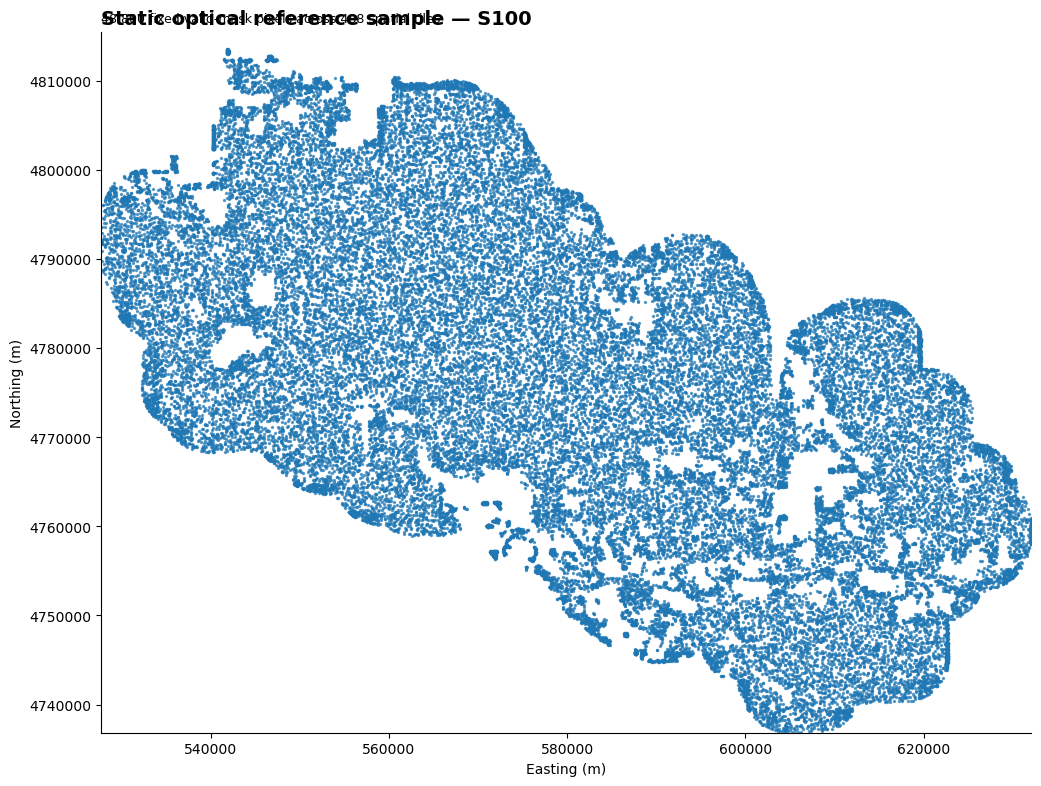

In [8]:
# =============================================================================
# 4C. SPATIAL QA MAP
# =============================================================================

s100 = sample_master.loc[
    sample_master[
        "in_s100"
    ]
].copy()

mask_display = np.ma.masked_where(
    ~valid_mask,
    valid_mask.astype(
        np.uint8
    ),
)

fig, ax = plt.subplots(
    figsize=(
        12,
        10,
    )
)

ax.imshow(
    mask_display,
    extent=[
        mask_bounds.left,
        mask_bounds.right,
        mask_bounds.bottom,
        mask_bounds.top,
    ],
    origin="upper",
    cmap="Greys",
    interpolation="none",
    alpha=0.55,
)

ax.scatter(
    s100[
        "Easting"
    ],
    s100[
        "Northing"
    ],
    s=2,
    alpha=0.65,
)

ax.set_title(
    "Static optical reference sample — S100",
    loc="left",
    fontsize=14,
    fontweight="bold",
)

ax.text(
    0.0,
    1.01,
    (
        f"{len(s100):,} fixed valid-mask pixels across "
        f"{s100['tile_id'].nunique():,} spatial tiles"
    ),
    transform=ax.transAxes,
    fontsize=9,
    ha="left",
    va="bottom",
)

ax.set_xlabel(
    "Easting (m)"
)

ax.set_ylabel(
    "Northing (m)"
)

ax.ticklabel_format(
    style="plain",
    axis="both",
    useOffset=False,
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

plt.show()


S100: 48,800 pixels | 488 tiles | saved -> C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45\static_optical_reference_sample_S100.png


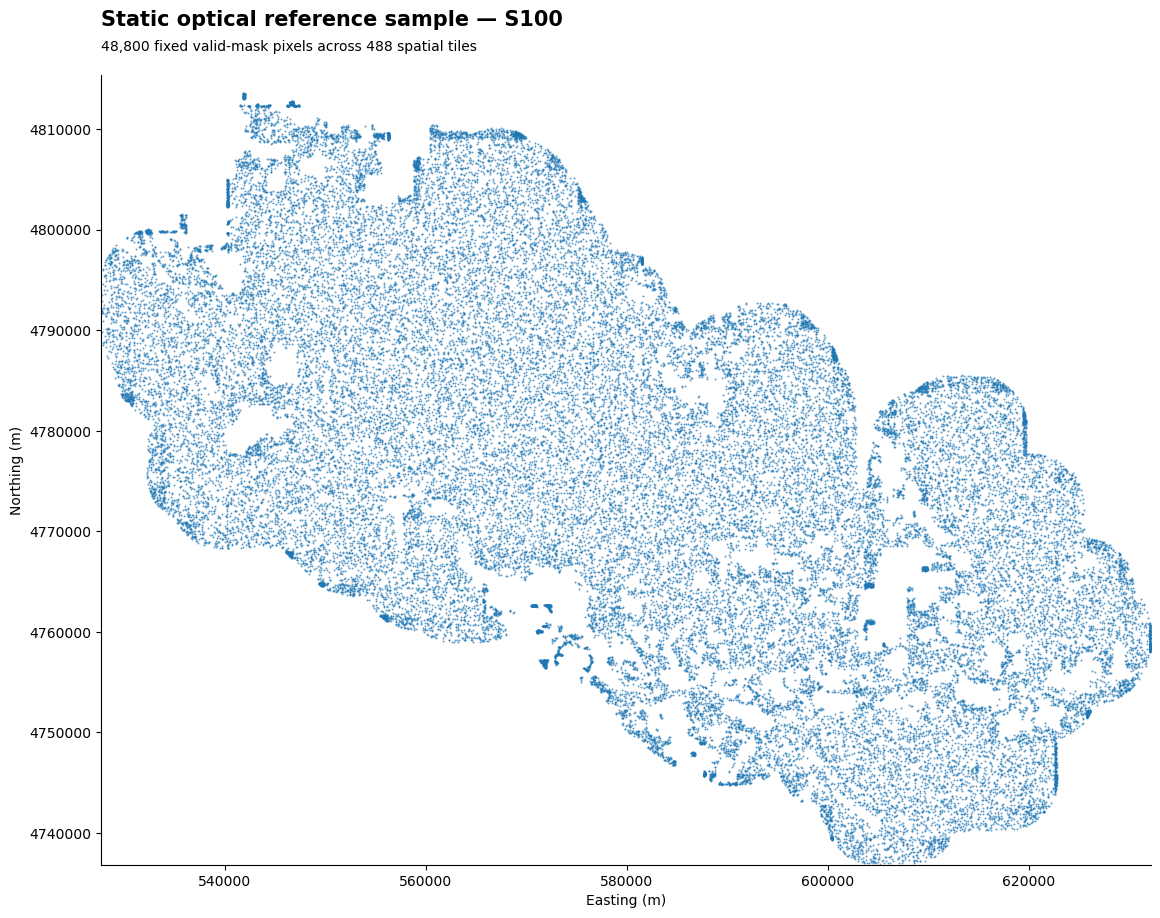

S250: 121,806 pixels | 488 tiles | saved -> C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45\static_optical_reference_sample_S250.png


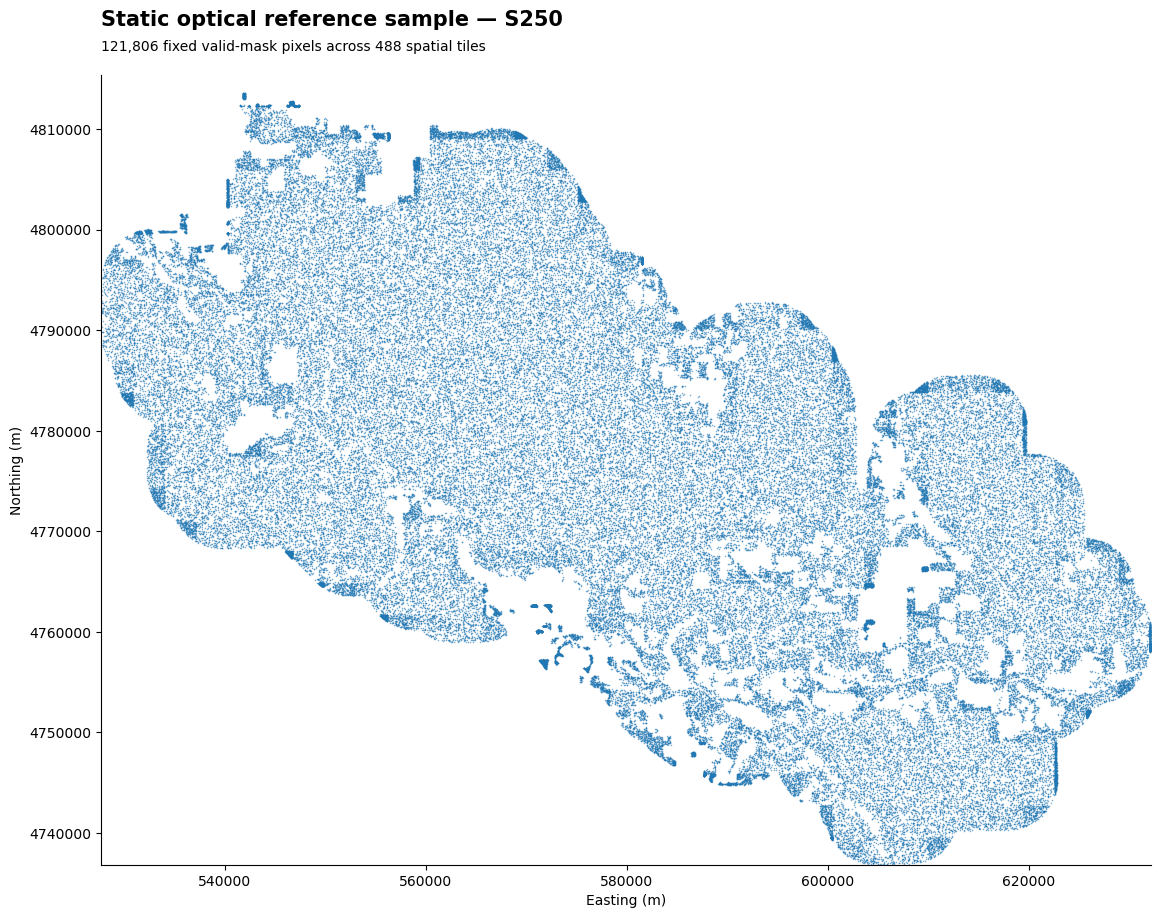

S500: 242,696 pixels | 488 tiles | saved -> C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45\static_optical_reference_sample_S500.png


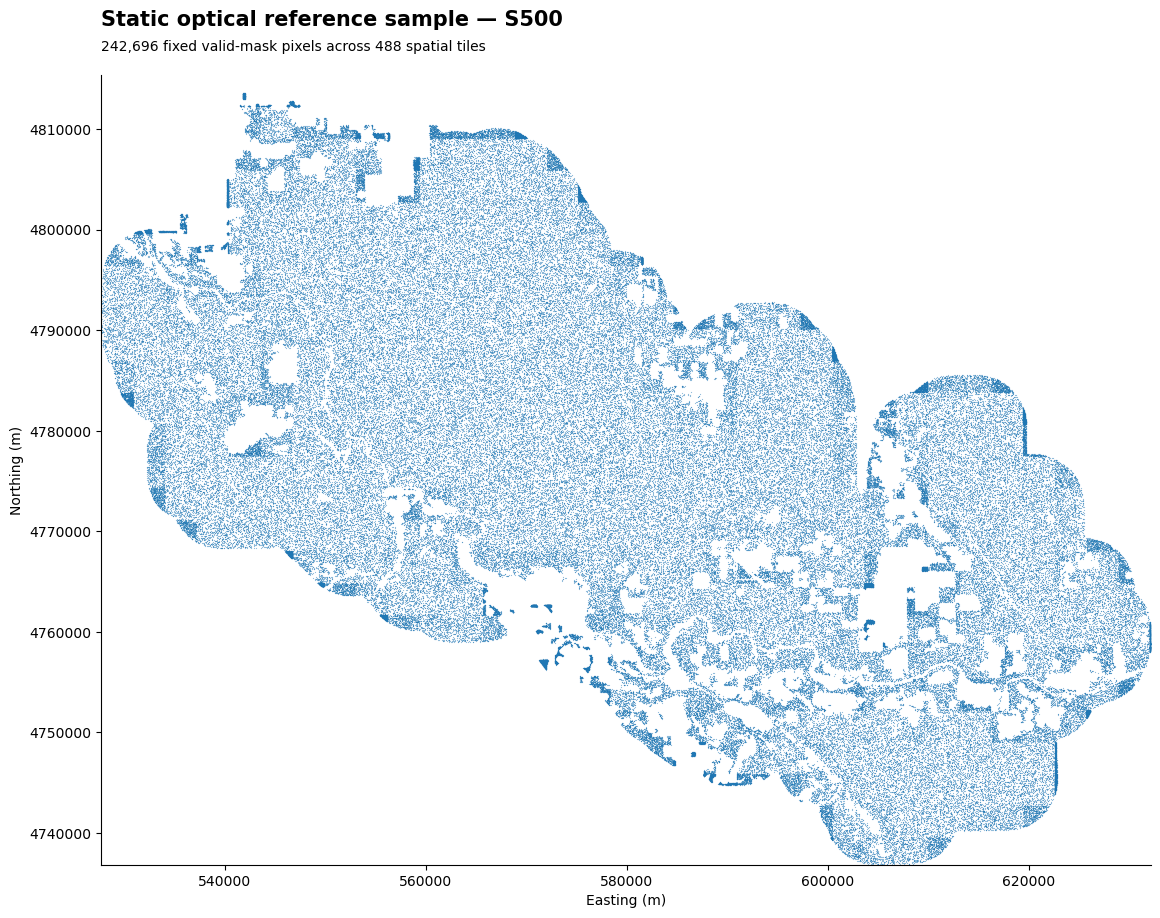

In [9]:
# =============================================================================
# 4C. SPATIAL QA MAPS — S100 / S250 / S500
# =============================================================================

# Background mask shown identically for all three figures.
mask_display = np.ma.masked_where(
    ~valid_mask,
    valid_mask.astype(
        np.uint8
    ),
)


# Slightly smaller points as sample density increases.
DISPLAY_SETTINGS = {
    100: {
        "size": 2.0,
        "alpha": 0.70,
    },
    250: {
        "size": 1.25,
        "alpha": 0.60,
    },
    500: {
        "size": 0.75,
        "alpha": 0.50,
    },
}


for tier in [
    100,
    250,
    500,
]:

    flag_col = (
        f"in_s{tier}"
    )


    sample_tier = sample_master.loc[
        sample_master[
            flag_col
        ]
    ].copy()


    # -------------------------------------------------------------------------
    # FIGURE
    # -------------------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            12,
            10,
        )
    )


    # Leave dedicated room above the axes for title + subtitle.
    fig.subplots_adjust(
        top=0.88,
        left=0.10,
        right=0.98,
        bottom=0.09,
    )


    # -------------------------------------------------------------------------
    # MASK
    # -------------------------------------------------------------------------

    ax.imshow(
        mask_display,
        extent=[
            mask_bounds.left,
            mask_bounds.right,
            mask_bounds.bottom,
            mask_bounds.top,
        ],
        origin="upper",
        cmap="Greys",
        interpolation="none",
        alpha=0.35,
    )


    # -------------------------------------------------------------------------
    # STATIC PIXEL SAMPLE
    # -------------------------------------------------------------------------

    ax.scatter(
        sample_tier[
            "Easting"
        ],
        sample_tier[
            "Northing"
        ],
        s=DISPLAY_SETTINGS[
            tier
        ][
            "size"
        ],
        alpha=DISPLAY_SETTINGS[
            tier
        ][
            "alpha"
        ],
        linewidths=0,
        rasterized=True,
    )


    # -------------------------------------------------------------------------
    # TITLE / SUBTITLE
    #
    # Use figure coordinates rather than ax.text() above the plotting area.
    # This avoids the recurring title/subtitle collision.
    # -------------------------------------------------------------------------

    axes_left = ax.get_position().x0


    fig.text(
        axes_left,
        0.945,
        (
            f"Static optical reference sample — S{tier}"
        ),
        fontsize=15,
        fontweight="bold",
        ha="left",
        va="top",
    )


    fig.text(
        axes_left,
        0.915,
        (
            f"{len(sample_tier):,} fixed valid-mask pixels across "
            f"{sample_tier['tile_id'].nunique():,} spatial tiles"
        ),
        fontsize=10,
        ha="left",
        va="top",
    )


    # -------------------------------------------------------------------------
    # AXES
    # -------------------------------------------------------------------------

    ax.set_xlabel(
        "Easting (m)"
    )

    ax.set_ylabel(
        "Northing (m)"
    )


    ax.ticklabel_format(
        style="plain",
        axis="both",
        useOffset=False,
    )


    ax.set_aspect(
        "equal"
    )


    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


    # -------------------------------------------------------------------------
    # OPTIONAL SAVE
    # -------------------------------------------------------------------------

    figure_path = (
        OUTPUT_DIR
        / (
            f"static_optical_reference_sample_"
            f"S{tier}.png"
        )
    )


    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )


    print(
        f"S{tier}: "
        f"{len(sample_tier):,} pixels | "
        f"{sample_tier['tile_id'].nunique():,} tiles | "
        f"saved -> {figure_path}"
    )


    plt.show()

    plt.close(
        fig
    )

In [15]:
# =============================================================================
# SAMPLE-DENSITY QA BY TILE
# =============================================================================

tile_density_qa = tiles[
    [
        "tile_id",
        "tile_grid_row",
        "tile_grid_col",
        "n_valid_pixels",
        "valid_area_km2",
    ]
].copy()


for tier in [
    100,
    250,
    500,
]:

    flag = f"in_s{tier}"

    counts = (
        sample_master.loc[
            sample_master[
                flag
            ]
        ]
        .groupby(
            "tile_id"
        )
        .size()
        .rename(
            f"n_s{tier}"
        )
    )


    tile_density_qa = tile_density_qa.merge(
        counts,
        left_on="tile_id",
        right_index=True,
        how="left",
    )


    tile_density_qa[
        f"n_s{tier}"
    ] = (
        tile_density_qa[
            f"n_s{tier}"
        ]
        .fillna(
            0
        )
        .astype(
            int
        )
    )


    tile_density_qa[
        f"density_s{tier}_per_km2"
    ] = (
        tile_density_qa[
            f"n_s{tier}"
        ]
        /
        tile_density_qa[
            "valid_area_km2"
        ]
    )


print(
    "Valid-area distribution among retained tiles:"
)

display(
    tile_density_qa[
        "valid_area_km2"
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)


print(
    "\nS500 sampling-density distribution:"
)

display(
    tile_density_qa[
        "density_s500_per_km2"
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)


print(
    "\nMost oversampled tiles:"
)

display(
    tile_density_qa
    .sort_values(
        "density_s500_per_km2",
        ascending=False,
    )
    .head(
        25
    )
)

Valid-area distribution among retained tiles:


count    488.000000
mean       7.178283
std        3.156263
min        0.016300
1%         0.084936
5%         0.419215
10%        2.050700
25%        5.060750
50%        8.701000
75%        9.869075
90%        9.984100
95%        9.985600
99%        9.985600
max        9.985600
Name: valid_area_km2, dtype: float64


S500 sampling-density distribution:


count      488.000000
mean       312.363668
std       1164.367018
min         50.072104
1%          50.072104
5%          50.072104
10%         50.079627
25%         50.663309
50%         57.465086
75%         98.799629
90%        243.833353
95%       1194.542997
99%       6038.562092
max      10000.000000
Name: density_s500_per_km2, dtype: float64


Most oversampled tiles:


,tile_id,tile_grid_row,tile_grid_col,n_valid_pixels,valid_area_km2,n_s100,density_s100_per_km2,n_s250,density_s250_per_km2,n_s500,density_s500_per_km2
462,T0463,22,18,233,0.0233,100,4291.845494,233,10000.000000,233,10000.000000
8,T0009,1,9,220,0.0220,100,4545.454545,220,10000.000000,220,10000.000000
483,T0484,24,22,163,0.0163,100,6134.969325,163,10000.000000,163,10000.000000
69,T0070,5,17,390,0.0390,100,2564.102564,250,6410.256410,390,10000.000000
413,T0414,18,33,190,0.0190,100,5263.157895,190,10000.000000,190,10000.000000
2,T0003,0,6,918,0.0918,100,1089.324619,250,2723.311547,500,5446.623094
347,T0348,16,13,1006,0.1006,100,994.035785,250,2485.089463,500,4970.178926
39,T0040,4,3,1125,0.1125,100,888.888889,250,2222.222222,500,4444.444444
372,T0373,17,13,1182,0.1182,100,846.023689,250,2115.059222,500,4230.118443
348,T0349,16,14,1198,0.1198,100,834.724541,250,2086.811352,500,4173.622705


## 5. Identify IA45 bands

This checks that every annual raster exposes the same 45 intercept + amplitude features in the same order.


In [10]:
# =============================================================================
# 5. IA45 BAND HELPERS
# =============================================================================

def annual_k2_path(
    year,
):

    return (
        HARMONIC_ROOT
        / str(year)
        / (
            f"{year}"
            "_K2_InterceptAmpPhase_nobs_RMSE.tif"
        )
    )


def get_band_names(
    src,
):

    return [
        (
            str(desc).strip()
            if desc is not None
            and str(desc).strip()
            else f"band_{i}"
        )
        for i, desc in enumerate(
            src.descriptions,
            start=1,
        )
    ]


def identify_ia45(
    src,
):

    all_names = get_band_names(
        src
    )

    keep = []

    for i, name in enumerate(
        all_names,
        start=1,
    ):

        lower = (
            str(name)
            .strip()
            .lower()
        )

        is_intercept = (
            re.search(
                r"(^|_)(intercept|constant)($|_)",
                lower,
            )
            is not None
        )

        is_amplitude = (
            re.search(
                r"(^|_)(amp|amplitude)",
                lower,
            )
            is not None
        )

        if (
            is_intercept
            or is_amplitude
        ):

            keep.append(
                (
                    i,
                    name,
                )
            )

    if len(
        keep
    ) != EXPECTED_IA45:

        raise ValueError(
            f"Expected {EXPECTED_IA45} IA45 bands, found {len(keep)}."
        )

    indexes = [
        x[0]
        for x in keep
    ]

    names = [
        x[1]
        for x in keep
    ]

    return (
        indexes,
        names,
    )


reference_names = None

band_qa_rows = []

for year in YEARS:

    path = annual_k2_path(
        year
    )

    if not path.exists():

        raise FileNotFoundError(
            f"Missing annual raster:\n{path}"
        )

    with rasterio.open(
        path
    ) as src:

        indexes, names = identify_ia45(
            src
        )

    if reference_names is None:

        reference_names = names

    same_order = (
        names
        == reference_names
    )

    band_qa_rows.append(
        {
            "Year": year,
            "n_ia45": len(
                names
            ),
            "same_band_names_and_order": same_order,
        }
    )

    if not same_order:

        raise ValueError(
            f"IA45 band-name/order mismatch in {year}."
        )

band_qa = pd.DataFrame(
    band_qa_rows
)

display(
    band_qa
)

band_qa.to_csv(
    OUTPUT_DIR
    / "static_optical_band_QA.csv",
    index=False,
)

print(
    "PASS: all annual rasters contain the same 45 IA bands in the same order."
)


,Year,n_ia45,same_band_names_and_order
0,2016,45,True
1,2017,45,True
2,2018,45,True
3,2019,45,True
4,2020,45,True
5,2021,45,True
6,2022,45,True
7,2023,45,True
8,2024,45,True
9,2025,45,True


PASS: all annual rasters contain the same 45 IA bands in the same order.


## 6. Extract IA45 at the same static locations in every year

Every annual output contains the full S500 point set plus:

- `Year`
- `valid_ia45`
- the 45 IA features

Invalid annual observations remain in the file with IA45 values set to `NaN`.

No annual means, SDs, or normalization statistics are calculated.


In [11]:
# =============================================================================
# 6A. SPARSE-WINDOW EXTRACTION HELPER
# =============================================================================

def extract_ia45_at_static_points(
    raster_path,
    points,
    expected_names,
    window_pixels=256,
):

    n_points = len(
        points
    )

    values = np.full(
        (
            n_points,
            len(
                expected_names
            ),
        ),
        np.nan,
        dtype=np.float32,
    )

    valid_ia45 = np.zeros(
        n_points,
        dtype=bool,
    )

    xs = points[
        "Easting"
    ].to_numpy(
        dtype=float
    )

    ys = points[
        "Northing"
    ].to_numpy(
        dtype=float
    )

    with rasterio.open(
        raster_path
    ) as src:

        indexes, names = identify_ia45(
            src
        )

        if names != expected_names:

            raise ValueError(
                f"IA45 band mismatch in:\n{raster_path}"
            )

        rows, cols = rowcol(
            src.transform,
            xs,
            ys,
        )

        rows = np.asarray(
            rows,
            dtype=np.int64,
        )

        cols = np.asarray(
            cols,
            dtype=np.int64,
        )

        inside = (
            (rows >= 0)
            & (rows < src.height)
            & (cols >= 0)
            & (cols < src.width)
        )

        inside_indices = np.where(
            inside
        )[0]

        work = pd.DataFrame(
            {
                "point_index": inside_indices,
                "row": rows[
                    inside_indices
                ],
                "col": cols[
                    inside_indices
                ],
            }
        )

        if len(
            work
        ) == 0:

            return (
                values,
                valid_ia45,
            )

        work[
            "window_row"
        ] = (
            work[
                "row"
            ]
            // window_pixels
        )

        work[
            "window_col"
        ] = (
            work[
                "col"
            ]
            // window_pixels
        )

        for (
            window_row,
            window_col,
        ), group in work.groupby(
            [
                "window_row",
                "window_col",
            ],
            sort=False,
        ):

            row0 = int(
                window_row
                * window_pixels
            )

            col0 = int(
                window_col
                * window_pixels
            )

            height = min(
                window_pixels,
                src.height
                - row0,
            )

            width = min(
                window_pixels,
                src.width
                - col0,
            )

            window = Window(
                col_off=col0,
                row_off=row0,
                width=width,
                height=height,
            )

            block = src.read(
                indexes,
                window=window,
                masked=False,
            ).astype(
                np.float32,
                copy=False,
            )

            point_idx = group[
                "point_index"
            ].to_numpy(
                dtype=np.int64
            )

            local_rows = (
                group[
                    "row"
                ].to_numpy(
                    dtype=np.int64
                )
                - row0
            )

            local_cols = (
                group[
                    "col"
                ].to_numpy(
                    dtype=np.int64
                )
                - col0
            )

            extracted = (
                block[
                    :,
                    local_rows,
                    local_cols,
                ]
                .T
            )

            valid = np.isfinite(
                extracted
            ).all(
                axis=1
            )

            if src.nodata is not None:

                valid &= ~np.any(
                    np.isclose(
                        extracted,
                        src.nodata,
                    ),
                    axis=1,
                )

            values[
                point_idx,
                :
            ] = extracted

            invalid_idx = point_idx[
                ~valid
            ]

            if len(
                invalid_idx
            ) > 0:

                values[
                    invalid_idx,
                    :
                ] = np.nan

            valid_ia45[
                point_idx
            ] = valid

    return (
        values,
        valid_ia45,
    )


In [12]:
# =============================================================================
# 6B. EXTRACT ALL YEARS
# =============================================================================

OVERWRITE_ANNUAL = False

annual_qa_rows = []

temporal_validity = pd.DataFrame(
    {
        "point_id": sample_master[
            "point_id"
        ].astype(str)
    }
)

for year in YEARS:

    print(
        "\n"
        + "=" * 100
    )

    print(
        f"PROCESSING {year}"
    )

    print(
        "=" * 100
    )

    raster_path = annual_k2_path(
        year
    )

    output_path = (
        OUTPUT_DIR
        / f"static_optical_IA45_{year}{ANNUAL_SUFFIX}"
    )

    t0 = time.perf_counter()

    if (
        output_path.exists()
        and not OVERWRITE_ANNUAL
    ):

        print(
            "Existing annual extraction found:",
            output_path
        )

        annual_existing = pd.read_csv(
            output_path,
            compression="gzip",
            usecols=[
                "point_id",
                "valid_ia45",
            ],
        )

        annual_valid = (
            annual_existing[
                "valid_ia45"
            ]
            .astype(str)
            .str.lower()
            .map(
                {
                    "true": True,
                    "false": False,
                }
            )
        )

        if annual_valid.isna().any():

            raise ValueError(
                f"Could not parse valid_ia45 in {output_path}"
            )

        annual_valid = annual_valid.to_numpy(
            dtype=bool
        )

    else:

        values, annual_valid = extract_ia45_at_static_points(
            raster_path=raster_path,
            points=sample_master,
            expected_names=reference_names,
            window_pixels=EXTRACTION_WINDOW_PIXELS,
        )

        annual_out = sample_master[
            [
                "point_id",
                "tile_id",
                "sample_rank",
                "mask_row",
                "mask_col",
                "Easting",
                "Northing",
                "in_s100",
                "in_s250",
                "in_s500",
            ]
        ].copy()

        annual_out.insert(
            1,
            "Year",
            year,
        )

        annual_out[
            "valid_ia45"
        ] = annual_valid

        for j, feature in enumerate(
            reference_names
        ):

            annual_out[
                feature
            ] = values[
                :,
                j
            ]

        annual_out.to_csv(
            output_path,
            index=False,
            compression="gzip",
            float_format="%.8g",
        )

        del values
        del annual_out

        print(
            "Wrote:",
            output_path
        )

    temporal_validity[
        f"valid_{year}"
    ] = annual_valid

    annual_qa_rows.append(
        {
            "Year": year,
            "n_static_points": len(
                sample_master
            ),
            "n_valid_ia45": int(
                annual_valid.sum()
            ),
            "valid_fraction": float(
                annual_valid.mean()
            ),
        }
    )

    print(
        f"{year}: {annual_valid.sum():,} / {len(annual_valid):,} "
        "static points have valid IA45"
    )

    print(
        "Elapsed:",
        f"{(time.perf_counter() - t0) / 60:.2f} min"
    )

annual_qa = pd.DataFrame(
    annual_qa_rows
)

annual_qa.to_csv(
    OUTPUT_DIR
    / "static_optical_annual_validity_QA.csv",
    index=False,
)

display(
    annual_qa
)



PROCESSING 2016
Existing annual extraction found: C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45\static_optical_IA45_2016.csv.gz
2016: 240,910 / 242,696 static points have valid IA45
Elapsed: 0.02 min

PROCESSING 2017
Existing annual extraction found: C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45\static_optical_IA45_2017.csv.gz
2017: 241,871 / 242,696 static points have valid IA45
Elapsed: 0.01 min

PROCESSING 2018
Existing annual extraction found: C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45\static_optical_IA45_2018.csv.gz
2018: 241,912 / 242,696 static points have valid IA45
Elapsed: 0.01 min

PROCESSING 2019
Existing annual extraction found: C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45\static_optical_IA45_2019.csv.gz
2019: 242,049 / 242,696 static points have valid IA45
Elapsed: 0.01 min

PROCESSING 2020
Existing annual extraction found: C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45\static_optical_IA45_2020.csv.gz
2020: 242,266 / 242,696 static points have valid IA45
Ela

,Year,n_static_points,n_valid_ia45,valid_fraction
0,2016,242696,240910,0.992641
1,2017,242696,241871,0.996601
2,2018,242696,241912,0.996770
3,2019,242696,242049,0.997334
4,2020,242696,242266,0.998228
5,2021,242696,242214,0.998014
6,2022,242696,242208,0.997989
7,2023,242696,242266,0.998228
8,2024,242696,242300,0.998368
9,2025,242696,242155,0.997771


## 7. Persistent temporal support QA

A sampled location is marked `persistent_valid=True` only when all 45 IA45 features are valid in every year from 2016–2025.

This does not calculate any spectral statistics. It only identifies the common temporal support.


In [13]:
# =============================================================================
# 7. PERSISTENT TEMPORAL SUPPORT
# =============================================================================

valid_cols = [
    f"valid_{year}"
    for year in YEARS
]

temporal_validity[
    "n_valid_years"
] = temporal_validity[
    valid_cols
].sum(
    axis=1
)

temporal_validity[
    "persistent_valid"
] = temporal_validity[
    valid_cols
].all(
    axis=1
)

sample_temporal = sample_master.merge(
    temporal_validity,
    on="point_id",
    how="left",
    validate="one_to_one",
)

sample_temporal.to_csv(
    OUTPUT_DIR
    / "static_optical_sample_temporal_coverage.csv",
    index=False,
)

qa_rows = []

for tier in SAMPLE_TIERS:

    tier_mask = (
        sample_temporal[
            "sample_rank"
        ].le(
            tier
        )
    )

    persistent_mask = (
        tier_mask
        & sample_temporal[
            "persistent_valid"
        ]
    )

    persistent_tier = (
        sample_temporal.loc[
            persistent_mask
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    persistent_tier.to_csv(
        OUTPUT_DIR
        / f"static_optical_sample_persistent_valid_S{tier}.csv",
        index=False,
    )

    qa_rows.append(
        {
            "sample_tier": f"S{tier}",
            "sampled_points": int(
                tier_mask.sum()
            ),
            "persistent_valid_points": int(
                persistent_mask.sum()
            ),
            "persistent_fraction": float(
                persistent_mask.sum()
                / tier_mask.sum()
            ),
        }
    )

persistent_qa = pd.DataFrame(
    qa_rows
)

persistent_qa.to_csv(
    OUTPUT_DIR
    / "static_optical_persistent_support_QA.csv",
    index=False,
)

display(
    persistent_qa
)

print(
    "\nSampling and extraction QA complete."
)

print(
    "No annual distribution statistics or z-scores were calculated."
)


,sample_tier,sampled_points,persistent_valid_points,persistent_fraction
0,S100,48800,48398,0.991762
1,S250,121806,120759,0.991404
2,S500,242696,240567,0.991228



Sampling and extraction QA complete.
No annual distribution statistics or z-scores were calculated.


TILE SUPPORT


,candidate_grid_tiles,retained_tiles,target_tile_area_km2,full_tile_area_km2,full_tile_pixels,median_valid_pixels_per_tile,min_valid_pixels_per_tile,max_valid_pixels_per_tile
0,850,488,10.0,9.986,99856,87010.0,163,99856



SAMPLE SIZE BY TIER


,sample_tier,points_if_every_tile_full,expected_points_given_mask,actual_points,tiles_with_full_requested_n,tiles_with_less_than_requested_n
0,S100,48800,48800,48800,488,0
1,S250,122000,121806,121806,484,4
2,S500,244000,242696,242696,483,5



TILE-LEVEL SAMPLING INTENSITY


,sample_tier,median_sampling_fraction,min_sampling_fraction,max_sampling_fraction,median_population_weight,min_population_weight,max_population_weight
0,S100,0.00115,0.00100,0.6135,870.10,1.63,998.560
1,S250,0.00287,0.00250,1.0000,348.04,1.00,399.424
2,S500,0.00575,0.00501,1.0000,174.02,1.00,199.712



10 SMALLEST VALID-SUPPORT TILES


,tile_id,n_valid_pixels,valid_area_km2,n_sample_S100,sampling_fraction_S100,population_weight_S100,n_sample_S250,sampling_fraction_S250,population_weight_S250,n_sample_S500,sampling_fraction_S500,population_weight_S500
483,T0484,163,0.0163,100,0.613497,1.63,163,1.000000,1.000,163,1.000000,1.000
413,T0414,190,0.0190,100,0.526316,1.90,190,1.000000,1.000,190,1.000000,1.000
8,T0009,220,0.0220,100,0.454545,2.20,220,1.000000,1.000,220,1.000000,1.000
462,T0463,233,0.0233,100,0.429185,2.33,233,1.000000,1.000,233,1.000000,1.000
69,T0070,390,0.0390,100,0.256410,3.90,250,0.641026,1.560,390,1.000000,1.000
2,T0003,918,0.0918,100,0.108932,9.18,250,0.272331,3.672,500,0.544662,1.836
347,T0348,1006,0.1006,100,0.099404,10.06,250,0.248509,4.024,500,0.497018,2.012
39,T0040,1125,0.1125,100,0.088889,11.25,250,0.222222,4.500,500,0.444444,2.250
372,T0373,1182,0.1182,100,0.084602,11.82,250,0.211506,4.728,500,0.423012,2.364
348,T0349,1198,0.1198,100,0.083472,11.98,250,0.208681,4.792,500,0.417362,2.396



10 LARGEST VALID-SUPPORT TILES


,tile_id,n_valid_pixels,valid_area_km2,n_sample_S100,sampling_fraction_S100,population_weight_S100,n_sample_S250,sampling_fraction_S250,population_weight_S250,n_sample_S500,sampling_fraction_S500,population_weight_S500
293,T0294,99856,9.9856,100,0.001001,998.56,250,0.002504,399.424,500,0.005007,199.712
296,T0297,99856,9.9856,100,0.001001,998.56,250,0.002504,399.424,500,0.005007,199.712
59,T0060,99856,9.9856,100,0.001001,998.56,250,0.002504,399.424,500,0.005007,199.712
60,T0061,99856,9.9856,100,0.001001,998.56,250,0.002504,399.424,500,0.005007,199.712
43,T0044,99856,9.9856,100,0.001001,998.56,250,0.002504,399.424,500,0.005007,199.712
48,T0049,99856,9.9856,100,0.001001,998.56,250,0.002504,399.424,500,0.005007,199.712
47,T0048,99856,9.9856,100,0.001001,998.56,250,0.002504,399.424,500,0.005007,199.712
470,T0471,99856,9.9856,100,0.001001,998.56,250,0.002504,399.424,500,0.005007,199.712
471,T0472,99856,9.9856,100,0.001001,998.56,250,0.002504,399.424,500,0.005007,199.712
469,T0470,99856,9.9856,100,0.001001,998.56,250,0.002504,399.424,500,0.005007,199.712


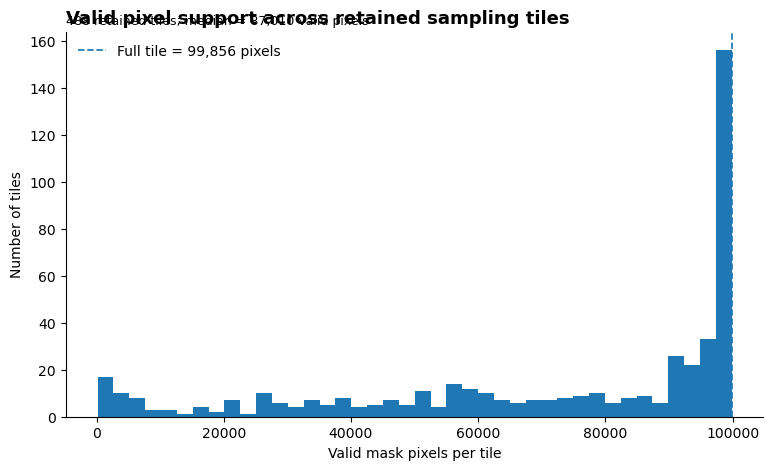


SAMPLING QA COMPLETE
Retained spatial tiles: 488
S100: 48,800 static pixels
S250: 121,806 static pixels
S500: 242,696 static pixels

NOTE:
Equal sampling per tile provides spatial balance.
It is not exactly self-weighting with respect to the full valid-pixel population because edge/fragmented tiles contain fewer valid pixels.
Tile-level N_h / n_h weights have therefore been retained as QA for the later annual-distribution workflow.


In [14]:
# =============================================================================
# FINAL SAMPLING-DESIGN DIAGNOSTICS
# =============================================================================

# This cell evaluates only the geometry and sampling intensity of the
# static optical sample.
#
# No IA45 distribution statistics or z-scores are calculated here.


# -----------------------------------------------------------------------------
# 1. TILE-SUPPORT SUMMARY
# -----------------------------------------------------------------------------

full_tile_pixels = (
    tile_side_pixels
    * tile_side_pixels
)

full_tile_area_km2 = (
    full_tile_pixels
    * pixel_area_m2
    / 1_000_000.0
)

tile_support_summary = pd.DataFrame(
    [
        {
            "candidate_grid_tiles": (
                n_tile_rows
                * n_tile_cols
            ),
            "retained_tiles": len(
                tiles
            ),
            "target_tile_area_km2": (
                TARGET_TILE_AREA_KM2
            ),
            "full_tile_area_km2": (
                full_tile_area_km2
            ),
            "full_tile_pixels": (
                full_tile_pixels
            ),
            "median_valid_pixels_per_tile": (
                tiles[
                    "n_valid_pixels"
                ].median()
            ),
            "min_valid_pixels_per_tile": (
                tiles[
                    "n_valid_pixels"
                ].min()
            ),
            "max_valid_pixels_per_tile": (
                tiles[
                    "n_valid_pixels"
                ].max()
            ),
        }
    ]
)

print(
    "TILE SUPPORT"
)

display(
    tile_support_summary.round(
        3
    )
)


# -----------------------------------------------------------------------------
# 2. SAMPLE SIZE BY TIER
# -----------------------------------------------------------------------------

tier_rows = []

for tier in SAMPLE_TIERS:

    expected_points = int(
        np.minimum(
            tier,
            tiles[
                "n_valid_pixels"
            ].to_numpy()
        ).sum()
    )

    actual_points = int(
        sample_master[
            "sample_rank"
        ].le(
            tier
        ).sum()
    )

    full_support_tiles = int(
        tiles[
            "n_valid_pixels"
        ].ge(
            tier
        ).sum()
    )

    limited_tiles = int(
        tiles[
            "n_valid_pixels"
        ].lt(
            tier
        ).sum()
    )

    tier_rows.append(
        {
            "sample_tier": f"S{tier}",
            "points_if_every_tile_full": (
                tier
                * len(
                    tiles
                )
            ),
            "expected_points_given_mask": (
                expected_points
            ),
            "actual_points": (
                actual_points
            ),
            "tiles_with_full_requested_n": (
                full_support_tiles
            ),
            "tiles_with_less_than_requested_n": (
                limited_tiles
            ),
        }
    )

tier_summary = pd.DataFrame(
    tier_rows
)

print(
    "\nSAMPLE SIZE BY TIER"
)

display(
    tier_summary
)


# -----------------------------------------------------------------------------
# 3. TILE-LEVEL SAMPLING INTENSITY
#
# Equal n per tile provides spatial balance, but the fraction of the local
# valid-pixel population sampled differs among tiles.
#
# The inverse sampling fraction:
#
#     N_h / n_h
#
# is the tile-level population weight that could later be used if annual
# means / SDs are intended to represent all valid mask pixels.
#
# We calculate it here ONLY as sampling-design QA.
# -----------------------------------------------------------------------------

sampling_intensity = tiles[
    [
        "tile_id",
        "n_valid_pixels",
        "valid_area_km2",
    ]
].copy()

for tier in SAMPLE_TIERS:

    n_col = (
        f"n_sample_S{tier}"
    )

    fraction_col = (
        f"sampling_fraction_S{tier}"
    )

    weight_col = (
        f"population_weight_S{tier}"
    )

    sampling_intensity[
        n_col
    ] = np.minimum(
        tier,
        sampling_intensity[
            "n_valid_pixels"
        ],
    )

    sampling_intensity[
        fraction_col
    ] = (
        sampling_intensity[
            n_col
        ]
        / sampling_intensity[
            "n_valid_pixels"
        ]
    )

    sampling_intensity[
        weight_col
    ] = (
        sampling_intensity[
            "n_valid_pixels"
        ]
        / sampling_intensity[
            n_col
        ]
    )


weight_summary_rows = []

for tier in SAMPLE_TIERS:

    weight_col = (
        f"population_weight_S{tier}"
    )

    fraction_col = (
        f"sampling_fraction_S{tier}"
    )

    weight_summary_rows.append(
        {
            "sample_tier": f"S{tier}",
            "median_sampling_fraction": (
                sampling_intensity[
                    fraction_col
                ].median()
            ),
            "min_sampling_fraction": (
                sampling_intensity[
                    fraction_col
                ].min()
            ),
            "max_sampling_fraction": (
                sampling_intensity[
                    fraction_col
                ].max()
            ),
            "median_population_weight": (
                sampling_intensity[
                    weight_col
                ].median()
            ),
            "min_population_weight": (
                sampling_intensity[
                    weight_col
                ].min()
            ),
            "max_population_weight": (
                sampling_intensity[
                    weight_col
                ].max()
            ),
        }
    )

weight_summary = pd.DataFrame(
    weight_summary_rows
)

print(
    "\nTILE-LEVEL SAMPLING INTENSITY"
)

display(
    weight_summary.round(
        5
    )
)


# -----------------------------------------------------------------------------
# 4. MOST FRAGMENTED / MOST COMPLETE TILES
# -----------------------------------------------------------------------------

print(
    "\n10 SMALLEST VALID-SUPPORT TILES"
)

display(
    sampling_intensity
    .sort_values(
        "n_valid_pixels"
    )
    .head(
        10
    )
)

print(
    "\n10 LARGEST VALID-SUPPORT TILES"
)

display(
    sampling_intensity
    .sort_values(
        "n_valid_pixels",
        ascending=False,
    )
    .head(
        10
    )
)


# -----------------------------------------------------------------------------
# 5. DISTRIBUTION OF VALID PIXEL SUPPORT ACROSS TILES
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(
        9,
        5,
    )
)

ax.hist(
    tiles[
        "n_valid_pixels"
    ],
    bins=40,
)

ax.axvline(
    full_tile_pixels,
    linestyle="--",
    linewidth=1.25,
    label=(
        f"Full tile = "
        f"{full_tile_pixels:,} pixels"
    ),
)

ax.set_title(
    "Valid pixel support across retained sampling tiles",
    loc="left",
    fontsize=13,
    fontweight="bold",
)

ax.text(
    0.0,
    1.01,
    (
        f"{len(tiles):,} retained tiles; "
        f"median = "
        f"{tiles['n_valid_pixels'].median():,.0f} valid pixels"
    ),
    transform=ax.transAxes,
    fontsize=9,
    ha="left",
    va="bottom",
)

ax.set_xlabel(
    "Valid mask pixels per tile"
)

ax.set_ylabel(
    "Number of tiles"
)

ax.legend(
    frameon=False
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

plt.show()


# -----------------------------------------------------------------------------
# 6. SAVE DIAGNOSTIC TABLES
# -----------------------------------------------------------------------------

tier_summary.to_csv(
    OUTPUT_DIR
    / "static_optical_sampling_tier_QA.csv",
    index=False,
)

sampling_intensity.to_csv(
    OUTPUT_DIR
    / "static_optical_tile_sampling_intensity_QA.csv",
    index=False,
)

weight_summary.to_csv(
    OUTPUT_DIR
    / "static_optical_sampling_weight_QA.csv",
    index=False,
)


# -----------------------------------------------------------------------------
# 7. FINAL MESSAGE
# -----------------------------------------------------------------------------

print(
    "\nSAMPLING QA COMPLETE"
)

print(
    f"Retained spatial tiles: "
    f"{len(tiles):,}"
)

for tier in SAMPLE_TIERS:

    n = int(
        sample_master[
            "sample_rank"
        ].le(
            tier
        ).sum()
    )

    print(
        f"S{tier}: "
        f"{n:,} static pixels"
    )

print(
    "\nNOTE:"
)

print(
    "Equal sampling per tile provides spatial balance."
)

print(
    "It is not exactly self-weighting with respect to the full valid-pixel "
    "population because edge/fragmented tiles contain fewer valid pixels."
)

print(
    "Tile-level N_h / n_h weights have therefore been retained as QA for "
    "the later annual-distribution workflow."
)

## Outputs

This notebook writes only sampling/extraction products and QA:

- `mask_v2_valid_pixel_summary.csv`
- `static_optical_tile_manifest.csv`
- `static_optical_sample_master_S500.csv`
- `static_optical_sample_S100.csv`
- `static_optical_sample_S250.csv`
- `static_optical_sample_S500.csv`
- `static_optical_band_QA.csv`
- `static_optical_IA45_2016.csv.gz` … `static_optical_IA45_2025.csv.gz`
- `static_optical_annual_validity_QA.csv`
- `static_optical_sample_temporal_coverage.csv`
- `static_optical_sample_persistent_valid_S100.csv`
- `static_optical_sample_persistent_valid_S250.csv`
- `static_optical_sample_persistent_valid_S500.csv`
- `static_optical_persistent_support_QA.csv`

The next workflow begins with these samples and separately estimates annual IA45 distributions and normalization parameters.


In [16]:
# =============================================================================
# THIN STATIC OPTICAL SAMPLE TO UNIFORM SPATIAL DENSITY
#
# Original design:
#   S100 / S250 / S500 = fixed number of points per retained tile
#
# Revised design:
#   S100 / S250 / S500 = constant point density across valid mask area
#
# Full ~10 km² tiles retain approximately:
#   S100 = 100
#   S250 = 250
#   S500 = 500
#
# Partial tiles are thinned in proportion to their valid area.
#
# IMPORTANT:
#   The original within-tile sample_rank was randomly ordered, so retaining
#   the earliest proportional fraction is still a random sample.
#
#   Existing IA45 values are SUBSETTED, not re-extracted from rasters.
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd


# -----------------------------------------------------------------------------
# PATHS
# -----------------------------------------------------------------------------

MASTER_PATH = (
    OUTPUT_DIR
    / "static_optical_sample_master_S500.csv"
)

TILE_PATH = (
    OUTPUT_DIR
    / "static_optical_tile_manifest.csv"
)

TEMPORAL_PATH = (
    OUTPUT_DIR
    / "static_optical_sample_temporal_coverage.csv"
)


# -----------------------------------------------------------------------------
# LOAD CURRENT SAMPLE + TILE SUPPORT
# -----------------------------------------------------------------------------

master_old = pd.read_csv(
    MASTER_PATH
)

tile_manifest = pd.read_csv(
    TILE_PATH
)


full_tile_area_km2 = (
    tile_manifest[
        "valid_area_km2"
    ].max()
)


tile_area_lookup = (
    tile_manifest
    .set_index(
        "tile_id"
    )[
        "valid_area_km2"
    ]
)


master_old[
    "_valid_area_km2"
] = master_old[
    "tile_id"
].map(
    tile_area_lookup
)


if master_old[
    "_valid_area_km2"
].isna().any():

    raise ValueError(
        "Some sampled points could not be matched "
        "to the tile manifest."
    )


# -----------------------------------------------------------------------------
# AREA FRACTION OF A FULL TILE
# -----------------------------------------------------------------------------

area_fraction = (
    master_old[
        "_valid_area_km2"
    ]
    /
    full_tile_area_km2
).clip(
    0.0,
    1.0,
)


# -----------------------------------------------------------------------------
# DENSITY-NORMALIZED SAMPLE RANK
#
# Example:
#
#   full tile:
#       fraction = 1.0
#       ranks remain 1..500
#
#   half-valid tile:
#       fraction = 0.5
#       old ranks 1..250 become approximately 2,4,...500
#
# Therefore:
#
#   sample_rank <= 100  -> ~100 * area_fraction points
#   sample_rank <= 250  -> ~250 * area_fraction points
#   sample_rank <= 500  -> ~500 * area_fraction points
#
# This lets the FCM notebook keep using:
#
#       sample_rank <= tier
#
# with NO downstream code changes.
# -----------------------------------------------------------------------------

new_rank = np.ceil(
    master_old[
        "sample_rank"
    ].to_numpy(
        dtype=np.float64
    )
    /
    area_fraction.to_numpy(
        dtype=np.float64
    )
).astype(
    np.int32
)


keep = (
    new_rank
    <= max(
        SAMPLE_TIERS
    )
)


sample_master = (
    master_old.loc[
        keep
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


sample_master[
    "sample_rank"
] = new_rank[
    keep
]


sample_master = sample_master.drop(
    columns=[
        "_valid_area_km2",
    ]
)


# -----------------------------------------------------------------------------
# REBUILD TIER FLAGS + WEIGHTS
# -----------------------------------------------------------------------------

for tier in SAMPLE_TIERS:

    flag_col = (
        f"in_s{tier}"
    )

    weight_col = (
        f"weight_s{tier}"
    )


    sample_master[
        flag_col
    ] = (
        sample_master[
            "sample_rank"
        ]
        <= tier
    )


    tier_counts = (
        sample_master.loc[
            sample_master[
                flag_col
            ]
        ]
        .groupby(
            "tile_id"
        )
        .size()
    )


    n_in_tile = (
        sample_master[
            "tile_id"
        ].map(
            tier_counts
        )
    )


    sample_master[
        weight_col
    ] = np.where(
        sample_master[
            flag_col
        ],
        (
            sample_master[
                "tile_valid_pixels"
            ]
            /
            n_in_tile
        ),
        np.nan,
    )


# -----------------------------------------------------------------------------
# OVERWRITE MASTER + TIER FILES
# -----------------------------------------------------------------------------

sample_master.to_csv(
    MASTER_PATH,
    index=False,
)


for tier in SAMPLE_TIERS:

    tier_df = sample_master.loc[
        sample_master[
            "sample_rank"
        ].le(
            tier
        )
    ].copy()


    tier_df.to_csv(
        OUTPUT_DIR
        / f"static_optical_sample_S{tier}.csv",
        index=False,
    )


# -----------------------------------------------------------------------------
# OVERWRITE ANNUAL IA45 FILES
#
# No raster extraction needed:
# retain only the new point_id set and update sampling metadata.
# -----------------------------------------------------------------------------

metadata_cols = [
    "sample_rank",
]

for tier in SAMPLE_TIERS:

    metadata_cols.extend(
        [
            f"in_s{tier}",
            f"weight_s{tier}",
        ]
    )


sample_lookup = (
    sample_master
    .set_index(
        "point_id"
    )
)


validity = pd.DataFrame(
    {
        "point_id":
            sample_master[
                "point_id"
            ].astype(
                str
            )
    }
)


annual_summary_rows = []


for year in YEARS:

    annual_path = (
        OUTPUT_DIR
        / f"static_optical_IA45_{year}{ANNUAL_SUFFIX}"
    )


    annual = pd.read_csv(
        annual_path,
        compression="gzip",
    )


    annual[
        "point_id"
    ] = annual[
        "point_id"
    ].astype(
        str
    )


    # Same ordering as the revised master sample.
    annual = (
        annual
        .set_index(
            "point_id"
        )
        .loc[
            sample_master[
                "point_id"
            ].astype(
                str
            )
        ]
        .reset_index()
    )


    # Update rank / tier metadata.
    for col in metadata_cols:

        if col in annual.columns:

            annual[
                col
            ] = annual[
                "point_id"
            ].map(
                sample_lookup[
                    col
                ]
            )


    annual.to_csv(
        annual_path,
        index=False,
        compression="gzip",
        float_format="%.8g",
    )


    annual_valid = (
        annual[
            "valid_ia45"
        ]
        .astype(str)
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
            }
        )
        .astype(bool)
        .to_numpy()
    )


    validity[
        f"valid_{year}"
    ] = annual_valid


    year_row = {
        "Year": year,
        "n_static_points": len(
            sample_master
        ),
        "inside_raster": np.nan,
        "valid_ia45": int(
            annual_valid.sum()
        ),
        "valid_fraction": float(
            annual_valid.mean()
        ),
    }


    for tier in SAMPLE_TIERS:

        tier_mask = (
            sample_master[
                "sample_rank"
            ]
            .le(
                tier
            )
            .to_numpy()
        )


        year_row[
            f"S{tier}_n"
        ] = int(
            tier_mask.sum()
        )


        year_row[
            f"S{tier}_valid"
        ] = int(
            (
                annual_valid
                & tier_mask
            ).sum()
        )


        year_row[
            f"S{tier}_valid_fraction"
        ] = float(
            annual_valid[
                tier_mask
            ].mean()
        )


    annual_summary_rows.append(
        year_row
    )


# -----------------------------------------------------------------------------
# REBUILD TEMPORAL COVERAGE + PERSISTENT SUPPORT
# -----------------------------------------------------------------------------

valid_cols = [
    f"valid_{year}"
    for year in YEARS
]


validity[
    "n_valid_years"
] = validity[
    valid_cols
].sum(
    axis=1
)


validity[
    "persistent_valid"
] = validity[
    valid_cols
].all(
    axis=1
)


sample_temporal = sample_master.merge(
    validity,
    on="point_id",
    how="left",
    validate="one_to_one",
)


sample_temporal.to_csv(
    TEMPORAL_PATH,
    index=False,
)


persistent_summary_rows = []


for tier in SAMPLE_TIERS:

    tier_mask = (
        sample_temporal[
            "sample_rank"
        ]
        <= tier
    )

    tier_persistent = (
        tier_mask
        & sample_temporal[
            "persistent_valid"
        ]
    )


    sample_temporal.loc[
        tier_persistent
    ].to_csv(
        OUTPUT_DIR
        / (
            "static_optical_sample_"
            f"persistent_valid_S{tier}.csv"
        ),
        index=False,
    )


    persistent_summary_rows.append(
        {
            "sample_tier": f"S{tier}",
            "sampled_points": int(
                tier_mask.sum()
            ),
            "persistent_valid_points": int(
                tier_persistent.sum()
            ),
            "persistent_fraction": float(
                tier_persistent.sum()
                /
                tier_mask.sum()
            ),
        }
    )


persistent_summary = pd.DataFrame(
    persistent_summary_rows
)


persistent_summary.to_csv(
    OUTPUT_DIR
    / "static_optical_persistent_support_summary.csv",
    index=False,
)


annual_extraction_summary = pd.DataFrame(
    annual_summary_rows
)


annual_extraction_summary.to_csv(
    OUTPUT_DIR
    / "static_optical_annual_extraction_summary.csv",
    index=False,
)


# -----------------------------------------------------------------------------
# QA — REALIZED DENSITY
# -----------------------------------------------------------------------------

qa_rows = []


for tier in SAMPLE_TIERS:

    tier_points = sample_master.loc[
        sample_master[
            "sample_rank"
        ]
        <= tier
    ]


    counts = (
        tier_points
        .groupby(
            "tile_id"
        )
        .size()
        .rename(
            "n"
        )
    )


    qa = (
        tile_manifest[
            [
                "tile_id",
                "valid_area_km2",
            ]
        ]
        .merge(
            counts,
            left_on="tile_id",
            right_index=True,
            how="left",
        )
    )


    qa[
        "n"
    ] = qa[
        "n"
    ].fillna(
        0
    )


    qa = qa.loc[
        qa[
            "n"
        ]
        > 0
    ].copy()


    qa[
        "density"
    ] = (
        qa[
            "n"
        ]
        /
        qa[
            "valid_area_km2"
        ]
    )


    qa_rows.append(
        {
            "tier": f"S{tier}",
            "n_points": len(
                tier_points
            ),
            "n_tiles": tier_points[
                "tile_id"
            ].nunique(),
            "target_density_per_km2": (
                tier
                /
                full_tile_area_km2
            ),
            "mean_realized_density": qa[
                "density"
            ].mean(),
            "median_realized_density": qa[
                "density"
            ].median(),
            "max_realized_density": qa[
                "density"
            ].max(),
        }
    )


density_qa = pd.DataFrame(
    qa_rows
)


print(
    "Original S500:",
    f"{len(master_old):,}",
)

print(
    "Uniform-density S500:",
    f"{len(sample_master):,}",
)

print()

display(
    density_qa.round(
        3
    )
)

print(
    "\nStatic optical sample outputs overwritten successfully."
)

Original S500: 242,696
Uniform-density S500: 175,170



,tier,n_points,n_tiles,target_density_per_km2,mean_realized_density,median_realized_density,max_realized_density
0,S100,34848,482,10.014,9.844,9.941,10.014
1,S250,87467,483,25.036,24.823,24.966,25.036
2,S500,175170,486,50.072,49.788,50.004,50.072



Static optical sample outputs overwritten successfully.


S100: 34,848 pixels | 482 tiles | 9.84 pixels/km²


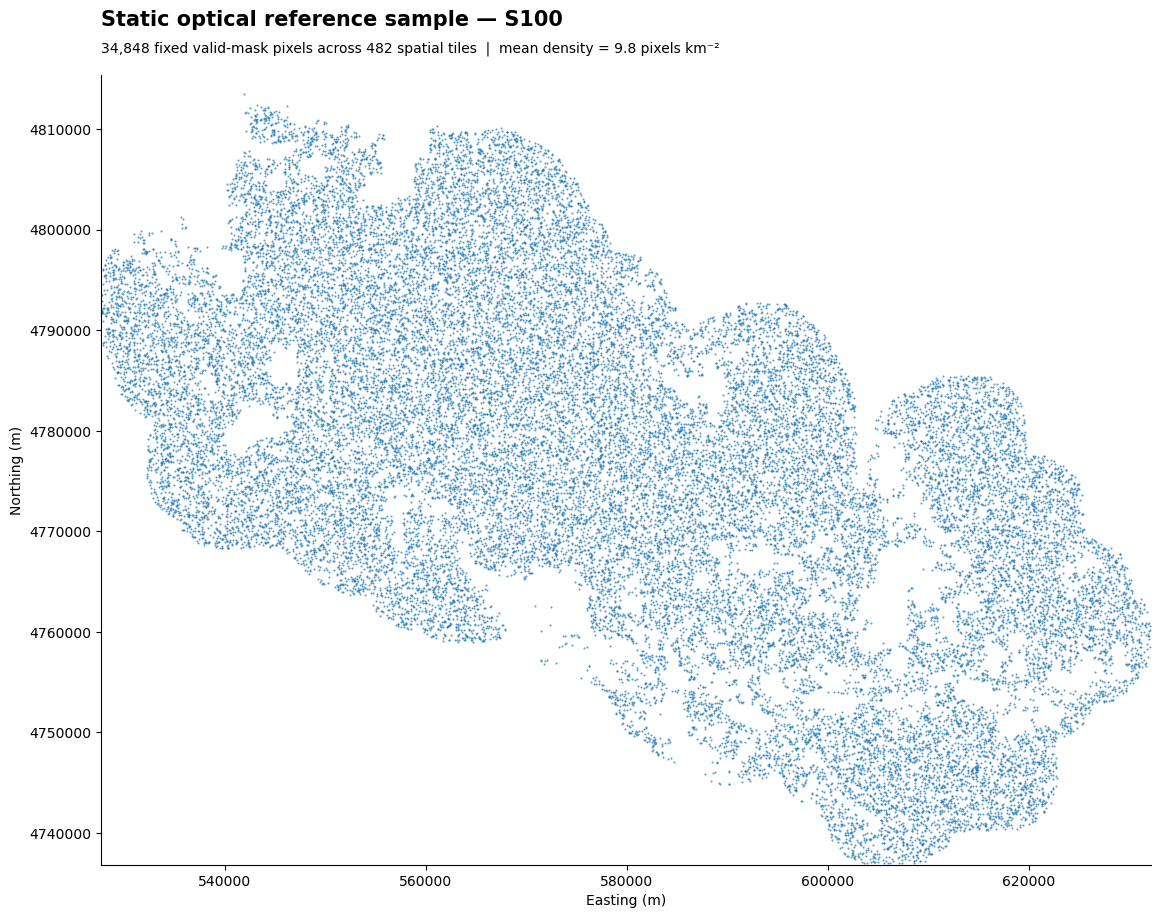

S250: 87,467 pixels | 483 tiles | 24.82 pixels/km²


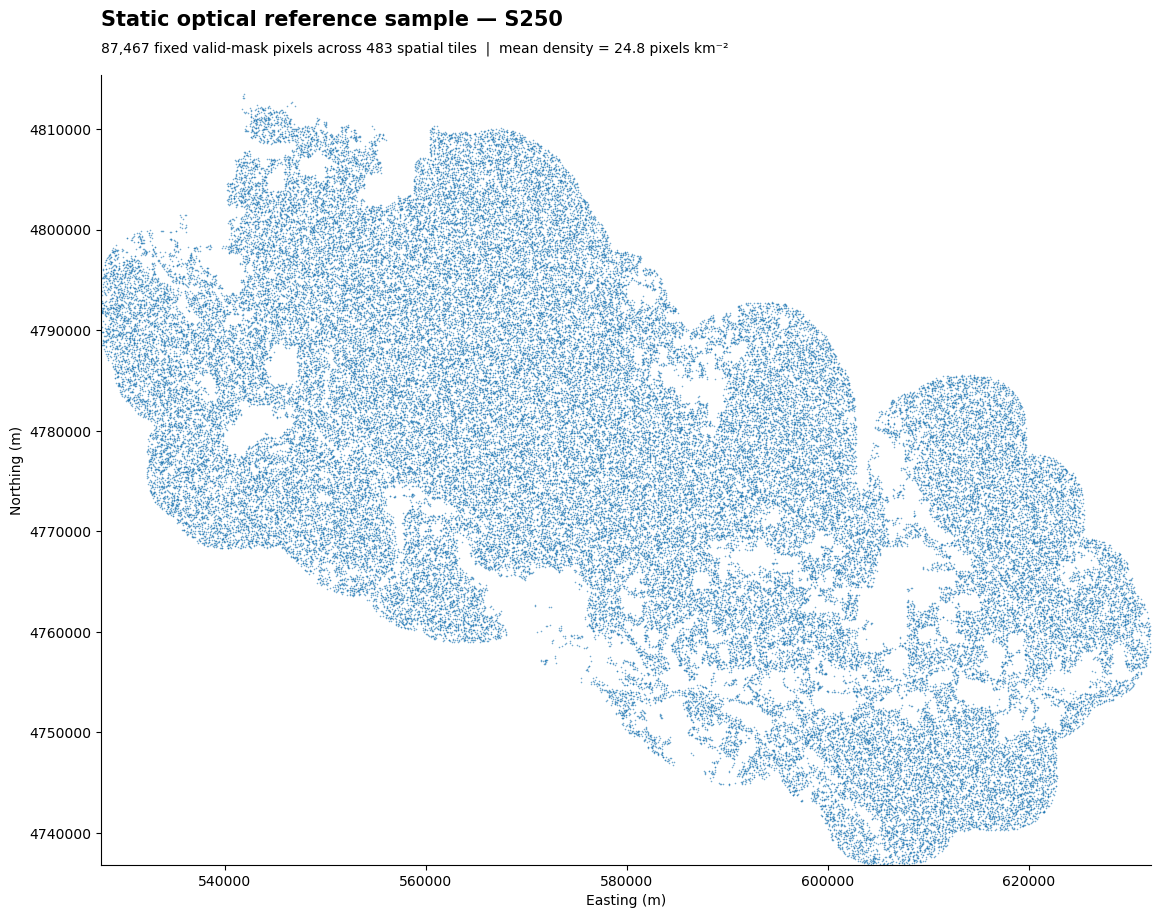

S500: 175,170 pixels | 486 tiles | 49.79 pixels/km²


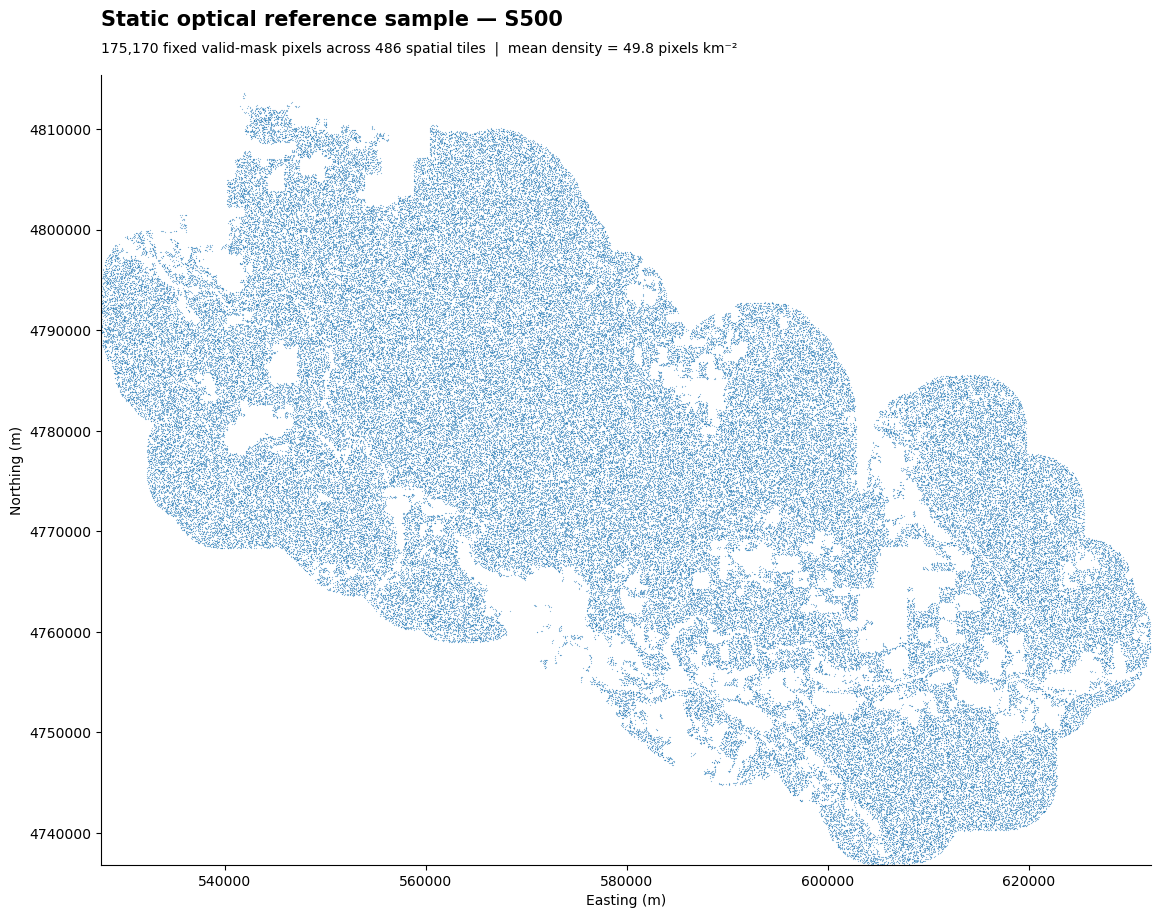

In [18]:
# =============================================================================
# VISUALIZE UNIFORM-DENSITY STATIC OPTICAL SAMPLES
# =============================================================================

mask_display = np.ma.masked_where(
    ~valid_mask,
    valid_mask.astype(
        np.uint8
    ),
)


DISPLAY_SETTINGS = {
    100: {
        "size": 2.2,
        "alpha": 0.72,
    },
    250: {
        "size": 1.3,
        "alpha": 0.62,
    },
    500: {
        "size": 0.75,
        "alpha": 0.52,
    },
}


for tier in [
    100,
    250,
    500,
]:

    # -------------------------------------------------------------------------
    # SELECT TIER
    # -------------------------------------------------------------------------

    sample_tier = sample_master.loc[
        sample_master[
            "sample_rank"
        ]
        <= tier
    ].copy()


    # -------------------------------------------------------------------------
    # REALIZED DENSITY
    # -------------------------------------------------------------------------

    tile_counts = (
        sample_tier
        .groupby(
            "tile_id"
        )
        .size()
        .rename(
            "n_points"
        )
    )


    density_df = (
        tiles[
            [
                "tile_id",
                "valid_area_km2",
            ]
        ]
        .merge(
            tile_counts,
            left_on="tile_id",
            right_index=True,
            how="left",
        )
    )


    density_df[
        "n_points"
    ] = density_df[
        "n_points"
    ].fillna(
        0
    )


    density_df = density_df.loc[
        density_df[
            "n_points"
        ]
        > 0
    ].copy()


    density_df[
        "density_per_km2"
    ] = (
        density_df[
            "n_points"
        ]
        /
        density_df[
            "valid_area_km2"
        ]
    )


    mean_density = density_df[
        "density_per_km2"
    ].mean()


    # -------------------------------------------------------------------------
    # FIGURE
    # -------------------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            12,
            10,
        )
    )


    fig.subplots_adjust(
        top=0.88,
        left=0.10,
        right=0.98,
        bottom=0.09,
    )


    # -------------------------------------------------------------------------
    # VALID MASK
    # -------------------------------------------------------------------------

    ax.imshow(
        mask_display,
        extent=[
            mask_bounds.left,
            mask_bounds.right,
            mask_bounds.bottom,
            mask_bounds.top,
        ],
        origin="upper",
        cmap="Greys",
        interpolation="none",
        alpha=0.22,
    )


    # -------------------------------------------------------------------------
    # SAMPLE POINTS
    # -------------------------------------------------------------------------

    ax.scatter(
        sample_tier[
            "Easting"
        ],
        sample_tier[
            "Northing"
        ],
        s=DISPLAY_SETTINGS[
            tier
        ][
            "size"
        ],
        alpha=DISPLAY_SETTINGS[
            tier
        ][
            "alpha"
        ],
        linewidths=0,
        rasterized=True,
    )


    # -------------------------------------------------------------------------
    # TITLE / SUBTITLE
    # -------------------------------------------------------------------------

    axes_left = ax.get_position().x0


    fig.text(
        axes_left,
        0.945,
        (
            f"Static optical reference sample — S{tier}"
        ),
        fontsize=15,
        fontweight="bold",
        ha="left",
        va="top",
    )


    fig.text(
        axes_left,
        0.914,
        (
            f"{len(sample_tier):,} fixed valid-mask pixels across "
            f"{sample_tier['tile_id'].nunique():,} spatial tiles  |  "
            f"mean density = {mean_density:.1f} pixels km⁻²"
        ),
        fontsize=10,
        ha="left",
        va="top",
    )


    # -------------------------------------------------------------------------
    # AXES
    # -------------------------------------------------------------------------

    ax.set_xlabel(
        "Easting (m)"
    )

    ax.set_ylabel(
        "Northing (m)"
    )


    ax.ticklabel_format(
        style="plain",
        axis="both",
        useOffset=False,
    )


    ax.set_aspect(
        "equal"
    )


    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


    # -------------------------------------------------------------------------
    # SAVE
    # -------------------------------------------------------------------------

    figure_path = (
        OUTPUT_DIR
        / (
            f"static_optical_reference_sample_"
            f"uniform_density_S{tier}.png"
        )
    )


    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )


    print(
        f"S{tier}: "
        f"{len(sample_tier):,} pixels | "
        f"{sample_tier['tile_id'].nunique():,} tiles | "
        f"{mean_density:.2f} pixels/km²"
    )


    plt.show()

    plt.close(
        fig
    )